<a href="https://colab.research.google.com/github/manish23454/Image_processing/blob/manish/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

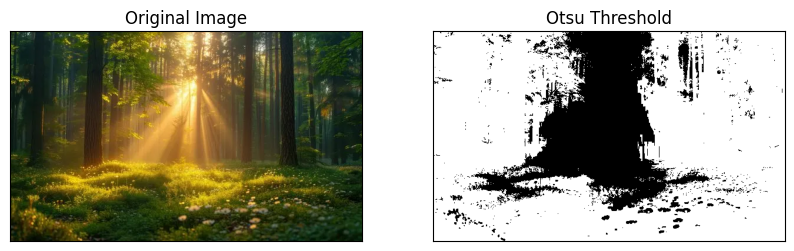

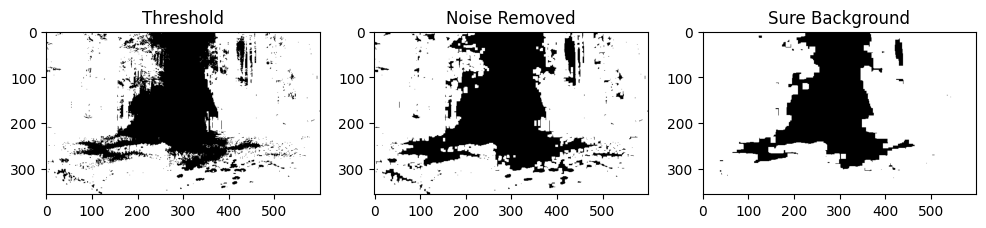

In [3]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

# Load original color image
img = cv.imread('/content/image.webp')

# Check whether image loaded correctly
if img is None:
    print("Image not found. Check file name/path.")
    exit()

# Convert BGR image to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Otsu thresholding
ret, thresh = cv.threshold(
    gray,
    0,
    255,
    cv.THRESH_BINARY_INV + cv.THRESH_OTSU
)

# Display images
plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.xticks([])
plt.yticks([])

plt.subplot(122)
plt.imshow(thresh, cmap='gray')
plt.title('Otsu Threshold')
plt.xticks([])
plt.yticks([])

plt.show()

# Noise removal using morphological opening
kernel = np.ones((3, 3), np.uint8)

opening = cv.morphologyEx(
    thresh,
    cv.MORPH_OPEN,
    kernel,
    iterations=2
)

# Sure background area
sure_bg = cv.dilate(opening, kernel, iterations=3)

# Show results
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(thresh, cmap='gray')
plt.title('Threshold')

plt.subplot(132)
plt.imshow(opening, cmap='gray')
plt.title('Noise Removed')

plt.subplot(133)
plt.imshow(sure_bg, cmap='gray')
plt.title('Sure Background')

plt.show()

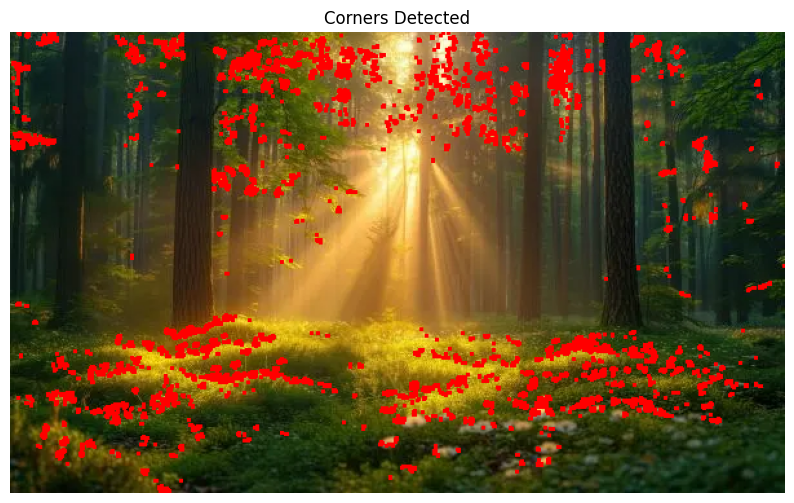

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#load the image
filename = '/content/image.webp' #ensutes this file is in your colab enviroment
img = cv2.imread(filename)

if img is None:
  raise FileNotFoundError(f"image file'{filename}' not found.")

#convert to grayScale
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

#Dilate result for better visiblity
dst = cv2.dilate(dst, None)

#Marks the corners in red
img[dst > 0.01 * dst.max()] = [0, 0, 255]

#Convert BGR to RGB for displaying with matplotlib

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Display the image
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.title('Corners Detected')
plt.axis('off')
plt.show()